In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
run_id = "biogpt_v1_V20260511_224220"
run_dir  = Path(f"outputs/train/runs/{run_id}/csv_logs")
versions = sorted(p.name for p in run_dir.iterdir() if p.name.startswith("version_"))
df = pd.concat([pd.read_csv(run_dir / v / "metrics.csv") for v in versions], ignore_index=True)


In [12]:
train_epoch = (
    df.dropna(subset=["train_loss_epoch"])
      .groupby("epoch", as_index=False)["train_loss_epoch"].last()
)
val_epoch = (
    df.dropna(subset=["val_loss_epoch"])
      .groupby("epoch", as_index=False)["val_loss_epoch"].last()
)
curves = train_epoch.merge(val_epoch, on="epoch", how="outer").sort_values("epoch")

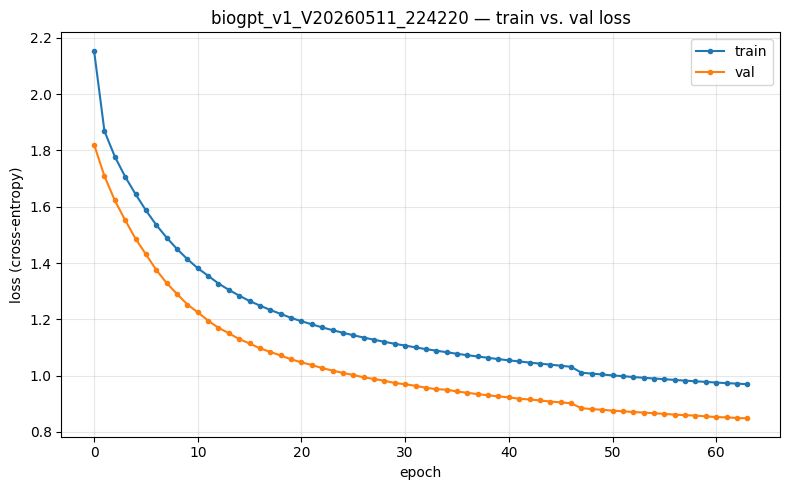

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(curves["epoch"], curves["train_loss_epoch"], marker="o", markersize=3, label="train")
ax.plot(curves["epoch"], curves["val_loss_epoch"], marker="o", markersize=3, label="val")
ax.set_xlabel("epoch")
ax.set_ylabel("loss (cross-entropy)")
ax.set_title(f"{run_id} — train vs. val loss")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()